In [11]:
from abc import ABC, abstractmethod
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Input
from tensorflow.keras.datasets import mnist
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
class MnistClassifierInterface(ABC):
    @abstractmethod
    def train(self, X_train, y_train):
        pass

    @abstractmethod
    def predict(self, X_test):
        pass


In [13]:
class RandomForestMnistClassifier(MnistClassifierInterface):
    def __init__(self):
        self.model = RandomForestClassifier(n_estimators=100)

    def train(self, X_train, y_train):
        self.model.fit(X_train, y_train)

    def predict(self, X_test):
        return self.model.predict(X_test)


In [14]:
class NeuralNetworkMnistClassifier(MnistClassifierInterface):
    def __init__(self):
        self.model = Sequential([
            Input(shape=(28, 28)),  
            Flatten(),
            Dense(128, activation='relu'),
            Dense(10, activation='softmax')
        ])
        self.model.compile(optimizer='adam',
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])

    def train(self, X_train, y_train):
        self.model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)

    def predict(self, X_test):
        return self.model.predict(X_test).argmax(axis=1)


In [15]:
class CnnMnistClassifier(MnistClassifierInterface):
    def __init__(self):
        self.model = Sequential([
            Input(shape=(28, 28, 1)),   # окремий Input шар
            Conv2D(32, kernel_size=(3,3), activation='relu'),
            MaxPooling2D(pool_size=(2,2)),
            Flatten(),
            Dense(128, activation='relu'),
            Dense(10, activation='softmax')
        ])
        self.model.compile(optimizer='adam',
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])

    def train(self, X_train, y_train):
        self.model.fit(X_train, y_train, epochs=6, batch_size=32, verbose=1)

    def predict(self, X_test):
        return self.model.predict(X_test).argmax(axis=1)

In [16]:
class MnistClassifier:
    def __init__(self, algorithm: str):
        if algorithm == "rf":
            self.classifier = RandomForestMnistClassifier()
        elif algorithm == "nn":
            self.classifier = NeuralNetworkMnistClassifier()
        elif algorithm == "cnn":
            self.classifier = CnnMnistClassifier()
        else:
            raise ValueError("Unsupported algorithm. Use 'rf', 'nn', or 'cnn'.")

    def train(self, X_train, y_train):
        self.classifier.train(X_train, y_train)

    def predict(self, X_test):
        return self.classifier.predict(X_test)


Training set size: (60000, 28, 28)
Test set size: (10000, 28, 28)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255
Class distribution in the training set:
Цифра 0: 5923 прикладів
Цифра 1: 6742 прикладів
Цифра 2: 5958 прикладів
Цифра 3: 6131 прикладів
Цифра 4: 5842 прикладів
Цифра 5: 5421 прикладів
Цифра 6: 5918 прикладів
Цифра 7: 6265 прикладів
Цифра 8: 5851 прикладів
Цифра 9: 5949 прикладів


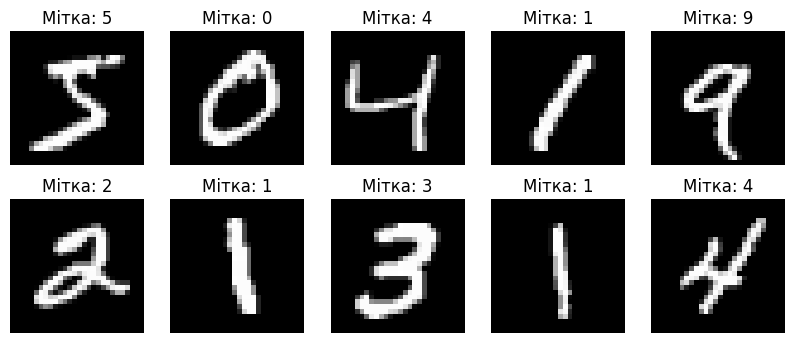

Average pixel value (float32): 33.318447
Pixel standard deviation (float32): 78.567444
Epoch 1/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9202 - loss: 0.2635
Epoch 2/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9856 - loss: 0.0479
Epoch 3/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9904 - loss: 0.0304
Epoch 4/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9936 - loss: 0.0208
Epoch 5/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9962 - loss: 0.0121
Epoch 6/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9970 - loss: 0.0095
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Приклади прогнозів: [7 2 1 0 4 1 4 9 5 9]


In [17]:
# Loading MNIST data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Basic information
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Data type:", X_train.dtype)
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
print("Class distribution in the training set:")
for digit, count in zip(unique, counts):
    print(f"Цифра {digit}: {count} прикладів")

# Visualization of examples
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Мітка: {y_train[i]}")
    plt.axis("off")
plt.show()

# Mean and standard deviation
mean_val = np.mean(X_train, dtype=np.float32)
std_val = np.std(X_train, dtype=np.float32)
print("Average pixel value (float32):", mean_val)
print("Pixel standard deviation (float32):", std_val)

# Normalization
X_train_norm = (X_train - mean_val) / std_val
X_test_norm = (X_test - mean_val) / std_val

# Transformation for CNN
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1).astype(np.float32)
X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1).astype(np.float32)

# Conversion for RF/NN
X_train_flat = X_train_norm.reshape(-1, 28*28).astype(np.float32)
X_test_flat = X_test_norm.reshape(-1, 28*28).astype(np.float32)

# Example: CNN classifier
clf = MnistClassifier("cnn")
clf.train(X_train_cnn, y_train)
predictions = clf.predict(X_test_cnn)
print("Приклади прогнозів:", predictions[:10])


In [18]:
# Example: Random Forest
clf_rf = MnistClassifier("rf")
clf_rf.train(X_train_flat, y_train)
predictions_rf = clf_rf.predict(X_test_flat)
print("RF predictions:", predictions_rf[:10])

# Example: Neural Network
clf_nn = MnistClassifier("nn")
clf_nn.train(X_train, y_train)  
predictions_nn = clf_nn.predict(X_test)
print("NN predictions:", predictions_nn[:10])

# Example: CNN 
clf_cnn = MnistClassifier("cnn")
clf_cnn.train(X_train_cnn, y_train)
predictions_cnn = clf_cnn.predict(X_test_cnn)
print("CNN predictions:", predictions_cnn[:10])


RF predictions: [7 2 1 0 4 1 4 9 5 9]
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8307 - loss: 6.5409
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9040 - loss: 0.4075
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9327 - loss: 0.2603
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9410 - loss: 0.2365
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9469 - loss: 0.2139
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step
NN predictions: [7 2 1 0 4 1 4 9 6 9]
Epoch 1/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9180 - loss: 0.2648
Epoch 2/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9848 - loss: 0.0500
Epoch 3/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9913 - loss: 0.0277
Epoch 4/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9944 - loss: 0.0195
Epoch 5/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9962 - loss: 0.0114
Epoch 

Classification report for NN:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.98      0.98      0.98      1135
           2       0.97      0.90      0.93      1032
           3       0.92      0.91      0.91      1010
           4       0.96      0.93      0.94       982
           5       0.91      0.94      0.92       892
           6       0.95      0.96      0.96       958
           7       0.97      0.93      0.95      1028
           8       0.86      0.94      0.90       974
           9       0.92      0.94      0.93      1009

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



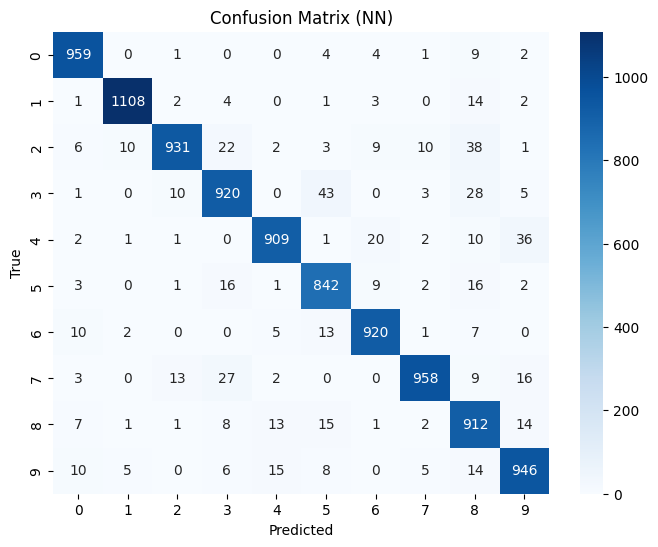

In [19]:

print("Classification report for NN:")
print(classification_report(y_test, predictions_nn))

# Матриця помилок
cm = confusion_matrix(y_test, predictions_nn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (NN)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


RF predictions: [7 2 1 0 4 1 4 9 5 9]

=== Random Forest Report ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.96      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.97      0.97       892
           6       0.97      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.96      0.96       974
           9       0.96      0.95      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



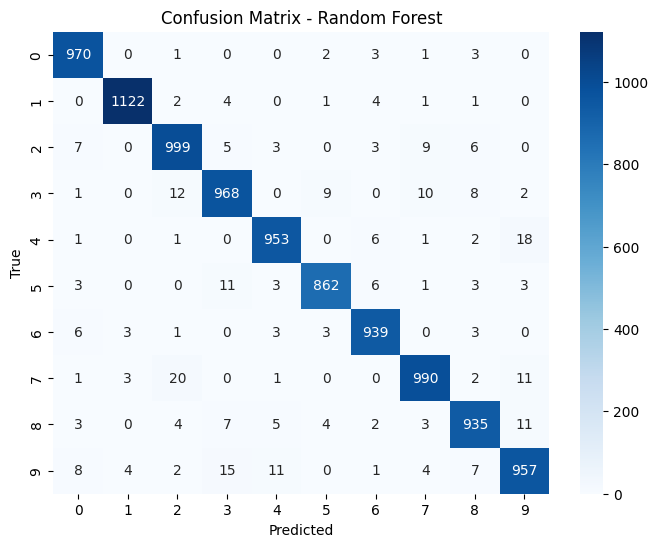

CNN predictions: [7 2 1 0 4 1 4 9 5 9]

=== CNN Report ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.98      0.99      0.98      1010
           4       0.98      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.98      1028
           8       0.96      0.99      0.98       974
           9       0.99      0.95      0.97      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



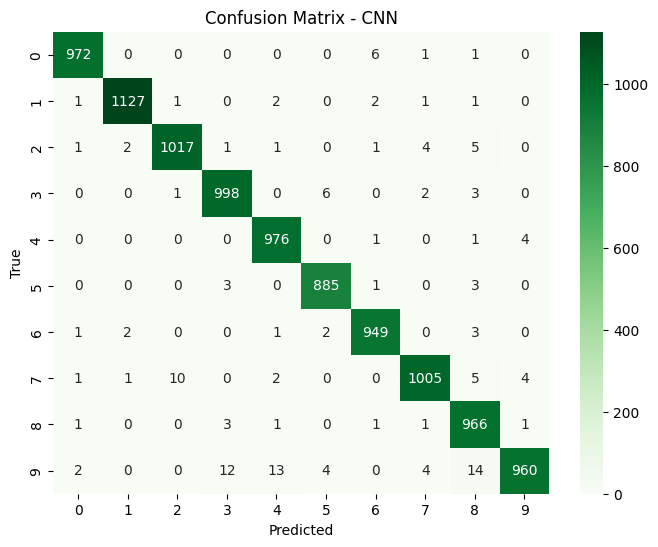

In [20]:
# --- Random Forest ---
print("RF predictions:", predictions_rf[:10])

print("\n=== Random Forest Report ===")
print(classification_report(y_test, predictions_rf))

cm_rf = confusion_matrix(y_test, predictions_rf)
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


# --- CNN ---
print("CNN predictions:", predictions_cnn[:10])

print("\n=== CNN Report ===")
print(classification_report(y_test, predictions_cnn))

cm_cnn = confusion_matrix(y_test, predictions_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
